<a href="https://colab.research.google.com/github/azholl/lis5693/blob/main/lab-5/lab-5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The deprecation warnings were getting annoying and slowing down my cell executions so I looked in Stack Overflow threads to see how to make them stop

In [47]:
import warnings

warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

Installing packages

In [48]:
!pip install gensim
!pip install pyldavis
!pip install nltk

Downloading list of English stopwords

In [49]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Importing libraries

In [50]:
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

Loading data from Github

In [51]:
import requests
import io

url = "https://raw.githubusercontent.com/azholl/lis5693/refs/heads/main/lab-5/lab-5-data.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

Save data as df

In [52]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

               Lens ID                                              Title  \
0  000-037-540-654-056                                         Long COVID   
1  000-425-845-807-513  Coping with long-COVID stigma: The role of sel...   
2  000-516-474-169-658  Age and chest computed tomography severity sco...   
3  000-521-509-636-014                           To Long COVID and Beyond   
4  000-579-570-485-747  Children with Long Covid: Co-producing a speci...   

   Publication Year                        Author/s  \
0            2023.0                 Kirsty R. Short   
1            2025.0      Maor Shani; Kilian Wübbelt   
2            2024.0                     Merve Erkan   
3            2021.0               David Misselbrook   
4            2021.0  Michael Fanner; Elaine Maxwell   

                                            Abstract  \
0                                                NaN   
1  Long COVID has been associated with stigmatiza...   
2  <AbstractText Label="INTRODUCTION">

My dataset comes from scholarly articles related to long covid. My search query in Lens.org was simply "long covid". I chose this dataset because long covid is a long-running interest of mine, and ties back into my greater focuses in the MLIS program of public health and disability justice.

**Task 2:**
Load first 10 rows of dataset

In [53]:
df = df[["Abstract"]]
df.head(10)

,Abstract
0,NaN
1,Long COVID has been associated with stigmatiza...
2,"<AbstractText Label=""INTRODUCTION"">About one-t..."
3,David Misselbrook ; ; ; ; New diseases don’t c...
4,"<jats:p>Globally, children have been profoundl..."
5,"<AbstractText Label=""OBJECTIVE"" NlmCategory=""O..."
6,<jats:p>Long COVID has been subject to growing...
7,NaN
8,<b>Background:</b> Long COVID can lead to a co...
9,People infected with coronavirus disease-19 (C...


**Rationale for choosing column:**
I chose the "Abstract" column for topic modeling because I thought it would have the most substantial keywords to pull in, moreso than the titles, because the abstracts give more context and go more in-depth.

In [54]:
docs = df["Abstract"].dropna().tolist()
print(docs[0])

Long COVID has been associated with stigmatization, prompting exploration of coping mechanisms. This cross-sectional study examined whether self-compassion and self-coldness mediate long-COVID stigma’s effects on well-being. We surveyed 201 German adults with long-COVID (89% female; Mage = 43.27, SD = 10.57). Most were officially diagnosed (88%), and 93% still experienced long-COVID symptoms at the time of survey. Measures included stigma, self-compassion, self-coldness, subjective well-being (SWB), and flourishing. Long-COVID stigma negatively correlated with SWB and flourishing. Higher self-compassion and lower self-coldness predicted better outcomes. Internalized stigma predicted lower flourishing through decreased self-compassion and increased self-coldness. In contrast, enacted stigma was associated with higher SWB and flourishing through lower self-coldness. Overall, mediation effects via self-coldness were significantly stronger than those via self-compassion, particularly in fl

**Task 3:** Preprocessing

In [55]:
stop_words = stopwords.words('english')

Function to clean the documents. Takes a document and returns a cleaned sequence of words with no punctuation or stop words.

In [56]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words

Adding custom stopwords. I started adding the stopwords whenever I saw the output of the code that mapped each number to their ID-Word index because I misunderstood that we were supposed to update the stopwords only to update the outputs of printing the top 5 words for each topic. I added more stopwords when I saw the output of that code, so that's why there are so many. I thought a lot of the top words that were appearing frequently were too general, I believe they were only the top words for each topic because of the context of the papers, and that they are not actually meaningful topic words. I also removed a few academic filler words. Am not sure if I am supposed to add that many stopwords but I do believe it gave me better, more relevant top topic words.

In [57]:
custom_stopwords = ['long', 'covid', 'study', 'research', 'patient', 'patients', 'background', 'introduction', 'method', 'methods', 'results', 'conclusion', 'discussion', 'article', 'paper', '2020', 'longcovid', 'diagnosed', 'diagnosis', 'examine', 'examination', 'examined', '1057',
'201', '4327', '88', '89', '93', 'whether', 'crosssectional', 'survey', 'surveyed', 'may', 'overall', 'covid19', 'jatssec', 'people', 'data', 'among', 'studies', 'sarscov2', 'abstracttext', 'individuals', 'also', 'reported', 'participants', 'ci', 'syndrome', 'including', '95', 'due', '2', 'using', 'analysis', 'used', 'cyp', 'coronavirus', 'compared', 'many', 'gps', '3', 'jatsp', 'group', 'symptom', 'symptoms', 'health', 'infection', 'acute', 'disease', 'care', 'risk']
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['long', 'covid', 'study', 'research', 'patient', 'patients', 'background', 'introduction', 'method', 'methods', 'results', 'conclusion', 'discussion', 'article', 'paper', '2020', 'longcovid', 'diagnosed', 'diagnosis', 'examine', 'examination', 'examined', '1057', '201', '4327', '88', '89', '93', 'whether', 'crosssectional', 'survey', 'surveyed', 'may', 'overall', 'covid19', 'jatssec', 'people', 'data', 'among', 'studies', 'sarscov2', 'abstracttext', 'individuals', 'also', 'reported', 'participants', 'ci', 'syndrome', 'including', '95', 'due', '2', 'using', 'analysis', 'used', 'cyp', 'coronavirus', 'compared', 'many', 'gps', '3', 'jatsp', 'group', 'symptom', 'symptoms', 'health', 'infection', 'acute', 'disease', 'care', 'risk']


Makes sure cleaning process, ID-Word Index, and Corpus have been regenerated with the new stopwords.

In [58]:
cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
Long COVID has been associated with stigmatization, prompting exploration of coping mechanisms. This cross-sectional study examined whether self-compassion and self-coldness mediate long-COVID stigma’s effects on well-being. We surveyed 201 German adults with long-COVID (89% female; Mage = 43.27, SD = 10.57). Most were officially diagnosed (88%), and 93% still experienced long-COVID symptoms at the time of survey. Measures included stigma, self-compassion, self-coldness, subjective well-being (SWB), and flourishing. Long-COVID stigma negatively correlated with SWB and flourishing. Higher self-compassion and lower self-coldness predicted better outcomes. Internalized stigma predicted lower flourishing through decreased self-compassion and increased self-coldness. In contrast, enacted stigma was associated with higher SWB and flourishing through lower self-coldness. Overa

Convert all documents into a list called clean docs

In [59]:
cleaned_docs = [clean_doc(doc) for doc in docs]

Create ID-Word index, LDA cannot look at words, everything must be converted to numbers

In [60]:
id2word = corpora.Dictionary(cleaned_docs)

Querying and seeing what word maps to index 250

In [61]:
id2word[250]

'profoundly'

Convert all documents into a sequence of numbers using doc2bow

In [62]:
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

In [63]:
print(corpus[0])

[(0, 1), (1, 1), (2, 2), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 2), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 5), (15, 1), (16, 2), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 3), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 2), (38, 1), (39, 1), (40, 1), (41, 1), (42, 7), (43, 6), (44, 1), (45, 1), (46, 5), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 3), (54, 1), (55, 2), (56, 3)]


Seeing what words the numbers correspond to by mapping each number to the ID-Word index

In [64]:
for num in corpus[0]:
    num = num[0]
    print(f"{num}\t{id2word[num]}")

0	adaptive
1	adults
2	associated
3	better
4	contrast
5	coping
6	correlated
7	decreased
8	effects
9	enacted
10	experienced
11	exploration
12	female
13	findings
14	flourishing
15	german
16	higher
17	highlight
18	holistic
19	included
20	increased
21	indicating
22	internalized
23	interplay
24	interventions
25	lower
26	mage
27	maladaptive
28	measures
29	mechanisms
30	mediate
31	mediation
32	negatively
33	officially
34	outcomes
35	particularly
36	pathways
37	predicted
38	promoting
39	prompting
40	reducing
41	sd
42	selfcoldness
43	selfcompassion
44	selfrelating
45	significantly
46	stigma
47	stigmatization
48	stigma’s
49	still
50	stronger
51	subjective
52	support
53	swb
54	time
55	via
56	wellbeing


Training topic model

In [65]:
lda_10 = LdaModel(corpus=corpus, id2word=id2word, num_topics=10)
lda_20 = LdaModel(corpus=corpus, id2word=id2word, num_topics=20)

Print top 5 words for each topic

In [66]:
lda_10.show_topics(num_words=5)

[(0,
  '0.005*"fatigue" + 0.004*"rehabilitation" + 0.004*"factors" + 0.004*"associated" + 0.003*"pandemic"'),
 (1,
  '0.005*"associated" + 0.004*"impact" + 0.004*"longterm" + 0.004*"months" + 0.003*"fatigue"'),
 (2,
  '0.005*"clinical" + 0.004*"adults" + 0.003*"condition" + 0.003*"children" + 0.003*"social"'),
 (3,
  '0.006*"fatigue" + 0.005*"clinical" + 0.004*"condition" + 0.004*"treatment" + 0.003*"longterm"'),
 (4,
  '0.004*"months" + 0.004*"prevalence" + 0.004*"clinical" + 0.003*"longterm" + 0.003*"fatigue"'),
 (5,
  '0.004*"longterm" + 0.004*"adults" + 0.004*"factors" + 0.004*"months" + 0.004*"condition"'),
 (6,
  '0.005*"cognitive" + 0.004*"treatment" + 0.003*"factors" + 0.003*"persistent" + 0.003*"management"'),
 (7,
  '0.006*"longterm" + 0.004*"clinical" + 0.004*"impact" + 0.003*"factors" + 0.003*"work"'),
 (8,
  '0.007*"fatigue" + 0.003*"longterm" + 0.003*"clinical" + 0.003*"impact" + 0.003*"months"'),
 (9,
  '0.004*"clinical" + 0.004*"impact" + 0.004*"cognitive" + 0.004*"long

In [67]:
lda_20.show_topics(num_words=5)

[(np.int64(12),
  '0.004*"months" + 0.003*"associated" + 0.003*"weeks" + 0.003*"management" + 0.003*"longterm"'),
 (np.int64(18),
  '0.008*"longterm" + 0.004*"condition" + 0.004*"chronic" + 0.004*"clinical" + 0.004*"management"'),
 (np.int64(14),
  '0.007*"fatigue" + 0.006*"healthcare" + 0.005*"condition" + 0.005*"prevalence" + 0.004*"longterm"'),
 (np.int64(0),
  '0.005*"fatigue" + 0.004*"vaccination" + 0.004*"one" + 0.004*"associated" + 0.003*"medical"'),
 (np.int64(15),
  '0.004*"months" + 0.004*"children" + 0.003*"impact" + 0.003*"adults" + 0.003*"years"'),
 (np.int64(19),
  '0.005*"fatigue" + 0.004*"clinical" + 0.004*"adults" + 0.004*"longterm" + 0.004*"rehabilitation"'),
 (np.int64(11),
  '0.006*"clinical" + 0.005*"associated" + 0.004*"management" + 0.004*"longterm" + 0.003*"rehabilitation"'),
 (np.int64(16),
  '0.004*"adults" + 0.004*"longterm" + 0.003*"treatment" + 0.003*"virus" + 0.003*"experienced"'),
 (np.int64(4),
  '0.005*"clinical" + 0.004*"associated" + 0.003*"prevalence

**Compare topic quality**
The 10 topic model output broad themes, and many of the topics contained very similar keywords (fatigue, treatment, clinical, longterm). Although the 20 topic model showed a lot of those same terms, it also had more variation across topics, including more specific terms (cognitive, mental, immune, autoimmune, respiratory, children, mecfs). This made the topics more distinct, even though there was still overlap.

**Which model is more interpretable**
I think the 20 topic model is more interpretable just because it narrowed down more specific themes and gave a clearer picture of the topic. The 10 topic model was too broad and repetitive.

**Creating facet bar graphs**: I got the error: "IndexError: index 20 is out of bounds for axis 0 with size 20", when I entered in 5, 10, 15, 20, and had to search to figure out that python starts indexing at 0, so I needed to reduce the number 20 by 1 to be within index range. I couldn't find much about this problem in this specific context, this is just overall information I gathered from different answers in various Stack Overflow and Github threads.

In [68]:
topic_data = []
target_topic_ids = [5, 10, 15, 19]

for topic_id in target_topic_ids:
    topic_terms = lda_20.show_topic(topic_id, topn=5)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID       Word  Probability
0         5   clinical     0.005953
1         5    fatigue     0.005928
2         5  treatment     0.004843
3         5   pandemic     0.004087
4         5    medical     0.003860


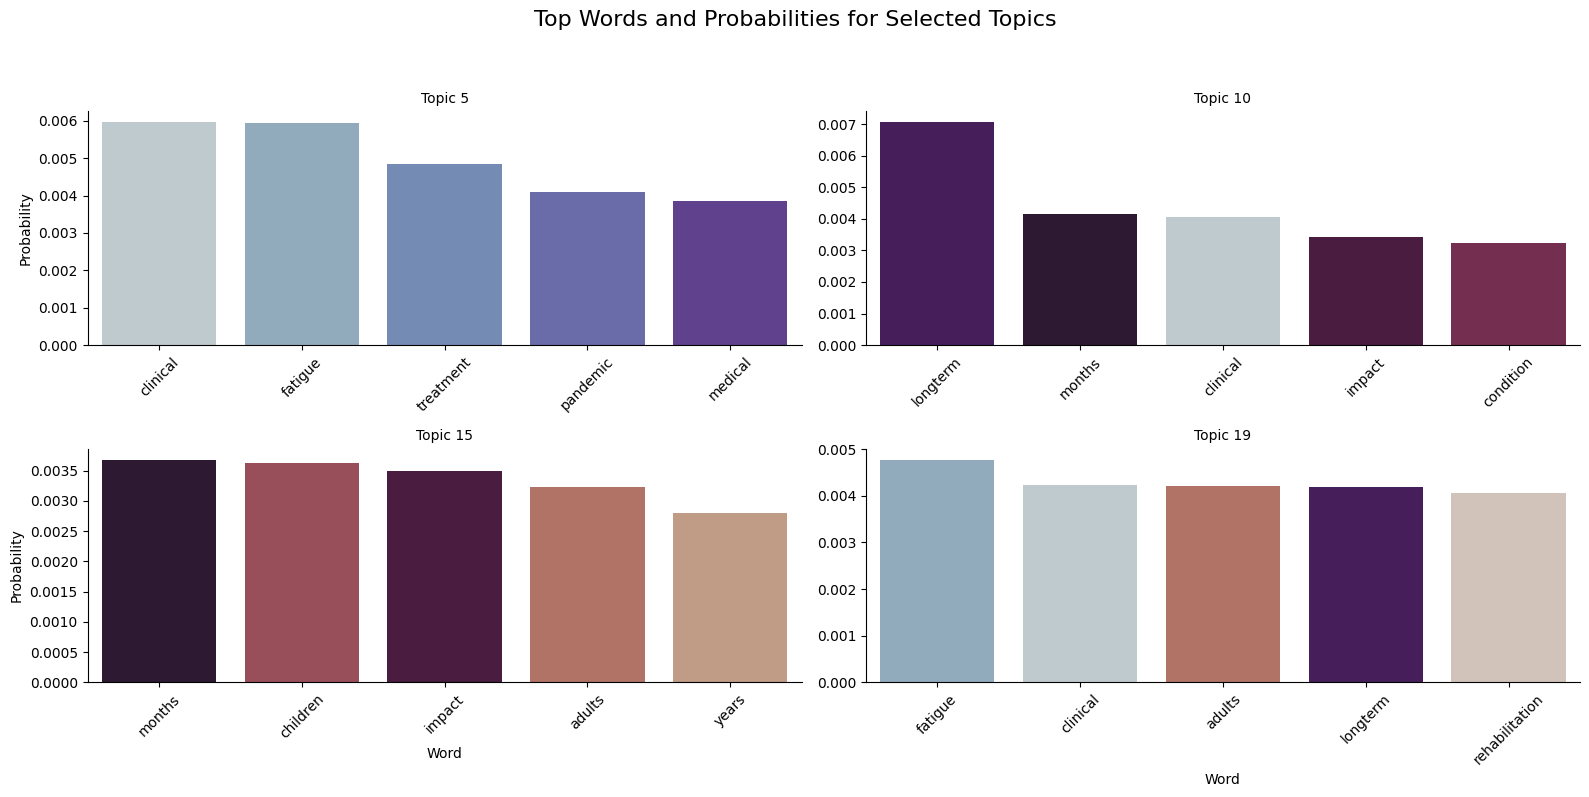

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

**Topic Labels**
Topic 5: Fatigue and Clinical Treatment

*   Topic 5: Fatigue and Clinical Treatment
*   Topic 10: Long-Term Impacts and Mental Health
*   Topic 15: Clinical Outcomes, Effect and Impact of COVID, Risk Factors
*   Topic 20: Cognitive and Chronic Associated Effects in Adults

**Which topics appear most distinct?** Topic 20 (19 technically) appears the most distinct because it includes the specific terms “cognitive” and “chronic,” which are not included in the other topics. Topic 10 is also distinct due to the inclusion of “vaccination” and “depression,” which highlight long COVID mental health issues and prevention aspects. The only word included in Topic 20 that is included in the other topics is "fatigue", which is a very relevant word in this context.

Topics 5, 10, and 15 overlap substantially because they share the terms“fatigue,” “clinical,” and “longterm.” These repeated keywords show that many of the topics are related to general long COVID symptoms and health outcomes, this makes this less clearly separated.

The top keywords align with my expectations for a dataset focused on long COVID. Terms like “fatigue,” “longterm,” “cognitive,”, "chronic", and “depression” reflect well-documented aspects of long COVID, including persistent symptoms, cognitive decline, and mental health impacts.

**Reflection:** The main thing I struggled with in this lab was what stopwords I should remove. I must have run the models over a dozen times trying to figure out what words to remove and, when I had removed too many, which ones I needed to add back in. When I didn't remove enough or the correct irrelevant words, a lot of general medical research language words were pulling as the top words, to the point that many top words for the topics were the same three or four words over and over. Whenever I removed too much, the models didn't have enough relevant words to draw from and started adding in irrelevant junk or other filler words I didn't consider to remove. I finally got the top words of each topic to something that I could work with, but I'm still not happy with it. This is an issue that I didn't consider before I chose this particular topic. I think the rest of the lab went well, as there were only a couple of parts I had problems with and needed to search on threads online to find solutions. In my current position as a GRA for a research project at OU, I'm not sure there would be any use for topic modeling, although I will consider it once I am coding data for the project this summer. I'm unsure of how topic modeling could be integrated in my future professional or research work, because I am unsure of what my future work will be.